# Notebook 03 — PPO-MLP + Frame Stacking sur CartPole-MaskedVelocity

**Objectif :** donner une **mémoire courte** à l'agent en empilant les `k=4` dernières observations. C'est la baseline "low-tech" face à un LSTM, et elle fonctionne très bien sur les POMDPs où l'information manquante est dérivable d'un historique court.

## Pourquoi Frame Stacking ?

CartPole-MaskedVelocity supprime les vitesses (x_dot, theta_dot). Mais ces vitesses peuvent être **reconstruites approximativement** comme différences finies de positions :

$$\dot{x}_t \approx x_t - x_{t-1}$$

Si l'agent voit les 4 dernières positions, il peut implicitement apprendre à calculer les vitesses dans son réseau. C'est exactement l'idée derrière le FrameStacking utilisé dans le DQN original (Mnih et al., 2015) pour Atari.

## Comparaison avec PPO-LSTM (NB 03b)

| Méthode | Mémoire | Complexité | Convergence |
|---|---|---|---|
| PPO-MLP + FrameStack | k frames fixes | Faible (MLP standard) | Stable, rapide |
| PPO-LSTM | État caché récurrent | Élevée | Instable, lente |

Frame Stacking est plus simple et souvent aussi performant pour des POMDPs où l'information manquante a une dépendance temporelle courte.

## Setup

In [8]:
import sys, os, random, time
from pathlib import Path
from dataclasses import dataclass

import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions.categorical import Categorical
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
print(f"ROOT = {ROOT}")

from src.envs.pomdp_wrappers import MaskVelocityWrapper, FrameStackWrapper

ROOT = c:\Users\Pape Malick\works\ppo-recurrent-pomdp


## Configuration

In [9]:
@dataclass
class Args:
    exp_name: str = "ppo_mlp_framestack_masked"
    seed: int = 1
    cuda: bool = True
    env_id: str = "CartPole-v1"
    total_timesteps: int = 300_000  # FrameStack converge bien, on vise 200+
    learning_rate: float = 2.5e-4
    anneal_lr: bool = True
    num_envs: int = 4
    num_steps: int = 128
    gamma: float = 0.99
    gae_lambda: float = 0.95
    num_minibatches: int = 4
    update_epochs: int = 4
    norm_adv: bool = True
    clip_coef: float = 0.2
    clip_vloss: bool = True
    ent_coef: float = 0.01
    vf_coef: float = 0.5
    max_grad_norm: float = 0.5
    framestack_k: int = 4

    @property
    def batch_size(self): return self.num_envs * self.num_steps
    @property
    def minibatch_size(self): return self.batch_size // self.num_minibatches
    @property
    def num_iterations(self): return self.total_timesteps // self.batch_size

args = Args()
run_name = f"{args.exp_name}__seed{args.seed}"
print(f"Run: {run_name}")

Run: ppo_mlp_framestack_masked__seed1


## Architecture (MLP standard, identique à NB 01)

In [10]:
def set_global_seed(seed, det=True):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = det

def layer_init(layer, std=np.sqrt(2), bias_const=0.0):
    torch.nn.init.orthogonal_(layer.weight, std)
    torch.nn.init.constant_(layer.bias, bias_const)
    return layer

class AgentMLP(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden_size=64):
        super().__init__()
        self.critic = nn.Sequential(
            layer_init(nn.Linear(obs_dim, hidden_size)), nn.Tanh(),
            layer_init(nn.Linear(hidden_size, hidden_size)), nn.Tanh(),
            layer_init(nn.Linear(hidden_size, 1), std=1.0),
        )
        self.actor = nn.Sequential(
            layer_init(nn.Linear(obs_dim, hidden_size)), nn.Tanh(),
            layer_init(nn.Linear(hidden_size, hidden_size)), nn.Tanh(),
            layer_init(nn.Linear(hidden_size, n_actions), std=0.01),
        )
    def get_value(self, x): return self.critic(x)
    def get_action_and_value(self, x, action=None):
        logits = self.actor(x)
        dist = Categorical(logits=logits)
        if action is None: action = dist.sample()
        return action, dist.log_prob(action), dist.entropy(), self.critic(x)

## Environnement avec MaskVelocity + FrameStack

L'observation passe par les wrappers dans cet ordre :
1. `MaskVelocityWrapper` : garde (x, θ), dim 2
2. `FrameStackWrapper(k=4)` : empile 4 dernières obs → dim 8

L'agent voit donc `[x_{t-3}, θ_{t-3}, x_{t-2}, θ_{t-2}, x_{t-1}, θ_{t-1}, x_t, θ_t]`.

In [11]:
def make_env(seed, idx):
    def thunk():
        env = gym.make(args.env_id)
        env = MaskVelocityWrapper(env)
        env = FrameStackWrapper(env, k=args.framestack_k)
        env = gym.wrappers.RecordEpisodeStatistics(env)
        env.action_space.seed(seed + idx)
        return env
    return thunk

set_global_seed(args.seed)
device = torch.device("cuda" if args.cuda and torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

envs = gym.vector.SyncVectorEnv([make_env(args.seed, i) for i in range(args.num_envs)])
obs_shape = envs.single_observation_space.shape
n_actions = envs.single_action_space.n
obs_dim = int(np.prod(obs_shape))
print(f"obs_shape={obs_shape} (devrait etre (8,) = 4 frames × 2 dims)")

Device: cpu
obs_shape=(8,) (devrait etre (8,) = 4 frames × 2 dims)


## Boucle d'entraînement (identique à PPO-MLP)

In [12]:
agent = AgentMLP(obs_dim, n_actions).to(device)
optimizer = optim.Adam(agent.parameters(), lr=args.learning_rate, eps=1e-5)

obs_buf = torch.zeros((args.num_steps, args.num_envs) + obs_shape, device=device)
actions_buf = torch.zeros((args.num_steps, args.num_envs), device=device)
logprobs_buf = torch.zeros((args.num_steps, args.num_envs), device=device)
rewards_buf = torch.zeros((args.num_steps, args.num_envs), device=device)
dones_buf = torch.zeros((args.num_steps, args.num_envs), device=device)
values_buf = torch.zeros((args.num_steps, args.num_envs), device=device)

history = {"step": [], "episodic_return": []}
global_step = 0
start = time.time()
next_obs, _ = envs.reset(seed=args.seed)
next_obs = torch.tensor(next_obs, dtype=torch.float32, device=device)
next_done = torch.zeros(args.num_envs, device=device)

for iteration in range(1, args.num_iterations + 1):
    if args.anneal_lr:
        frac = 1.0 - (iteration - 1) / args.num_iterations
        for pg in optimizer.param_groups: pg["lr"] = frac * args.learning_rate

    for step in range(args.num_steps):
        global_step += args.num_envs
        obs_buf[step] = next_obs
        dones_buf[step] = next_done
        with torch.no_grad():
            action, logprob, _, value = agent.get_action_and_value(next_obs)
            values_buf[step] = value.flatten()
        actions_buf[step] = action
        logprobs_buf[step] = logprob
        obs_np, reward, term, trunc, info = envs.step(action.cpu().numpy())
        rewards_buf[step] = torch.tensor(reward, dtype=torch.float32, device=device)
        done_np = np.logical_or(term, trunc)
        next_obs = torch.tensor(obs_np, dtype=torch.float32, device=device)
        next_done = torch.tensor(done_np, dtype=torch.float32, device=device)
        if "final_info" in info:
            for ei in info["final_info"]:
                if ei and "episode" in ei:
                    history["step"].append(global_step)
                    history["episodic_return"].append(float(ei["episode"]["r"]))
        elif "episode" in info and "_episode" in info:
            mask = info["_episode"]
            if np.any(mask):
                for idx in np.where(mask)[0]:
                    history["step"].append(global_step)
                    history["episodic_return"].append(float(info["episode"]["r"][idx]))

    with torch.no_grad():
        next_value = agent.get_value(next_obs).reshape(1, -1)
        advantages = torch.zeros_like(rewards_buf)
        lastgaelam = 0.0
        for t in reversed(range(args.num_steps)):
            if t == args.num_steps - 1:
                nextnonterm = 1.0 - next_done; nextvals = next_value
            else:
                nextnonterm = 1.0 - dones_buf[t+1]; nextvals = values_buf[t+1]
            delta = rewards_buf[t] + args.gamma * nextvals * nextnonterm - values_buf[t]
            advantages[t] = lastgaelam = delta + args.gamma * args.gae_lambda * nextnonterm * lastgaelam
        returns = advantages + values_buf

    b_obs = obs_buf.reshape((-1,) + obs_shape)
    b_logprobs = logprobs_buf.reshape(-1)
    b_actions = actions_buf.reshape(-1).long()
    b_advantages = advantages.reshape(-1)
    b_returns = returns.reshape(-1)
    b_values = values_buf.reshape(-1)
    b_inds = np.arange(args.batch_size)

    for epoch in range(args.update_epochs):
        np.random.shuffle(b_inds)
        for s in range(0, args.batch_size, args.minibatch_size):
            mb = b_inds[s:s+args.minibatch_size]
            _, newlogprob, entropy, newvalue = agent.get_action_and_value(b_obs[mb], b_actions[mb])
            logratio = newlogprob - b_logprobs[mb]
            ratio = logratio.exp()
            mb_adv = b_advantages[mb]
            if args.norm_adv:
                mb_adv = (mb_adv - mb_adv.mean()) / (mb_adv.std() + 1e-8)
            pg_loss1 = -mb_adv * ratio
            pg_loss2 = -mb_adv * torch.clamp(ratio, 1-args.clip_coef, 1+args.clip_coef)
            pg_loss = torch.max(pg_loss1, pg_loss2).mean()
            newvalue = newvalue.view(-1)
            if args.clip_vloss:
                v_clipped = b_values[mb] + torch.clamp(newvalue - b_values[mb], -args.clip_coef, args.clip_coef)
                v_loss = 0.5 * torch.max((newvalue-b_returns[mb])**2, (v_clipped-b_returns[mb])**2).mean()
            else:
                v_loss = 0.5 * ((newvalue-b_returns[mb])**2).mean()
            ent_loss = entropy.mean()
            loss = pg_loss - args.ent_coef * ent_loss + args.vf_coef * v_loss
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(agent.parameters(), args.max_grad_norm)
            optimizer.step()

    if iteration % 20 == 0 or iteration == 1:
        recent = history["episodic_return"][-30:] if history["episodic_return"] else [0]
        sps = int(global_step / (time.time() - start))
        print(f"iter {iteration:4d} | step {global_step:7d} | return(30)={np.mean(recent):6.1f} | SPS={sps}")

envs.close()
print(f"\nDurée : {time.time()-start:.1f}s")

iter    1 | step     512 | return(30)=  20.6 | SPS=930
iter   20 | step   10240 | return(30)=  41.4 | SPS=2644
iter   40 | step   20480 | return(30)=  32.6 | SPS=3026
iter   60 | step   30720 | return(30)=  40.1 | SPS=3240
iter   80 | step   40960 | return(30)=  37.3 | SPS=3344
iter  100 | step   51200 | return(30)=  38.7 | SPS=3419
iter  120 | step   61440 | return(30)=  81.9 | SPS=3440
iter  140 | step   71680 | return(30)= 106.2 | SPS=3409
iter  160 | step   81920 | return(30)= 121.0 | SPS=3406
iter  180 | step   92160 | return(30)= 166.5 | SPS=3377
iter  200 | step  102400 | return(30)= 145.1 | SPS=3350
iter  220 | step  112640 | return(30)= 174.0 | SPS=3298
iter  240 | step  122880 | return(30)= 151.3 | SPS=3290
iter  260 | step  133120 | return(30)= 208.9 | SPS=3286
iter  280 | step  143360 | return(30)= 261.2 | SPS=3276
iter  300 | step  153600 | return(30)= 221.0 | SPS=3265
iter  320 | step  163840 | return(30)= 200.6 | SPS=3268
iter  340 | step  174080 | return(30)= 262.6 | SP

## Courbe d'apprentissage

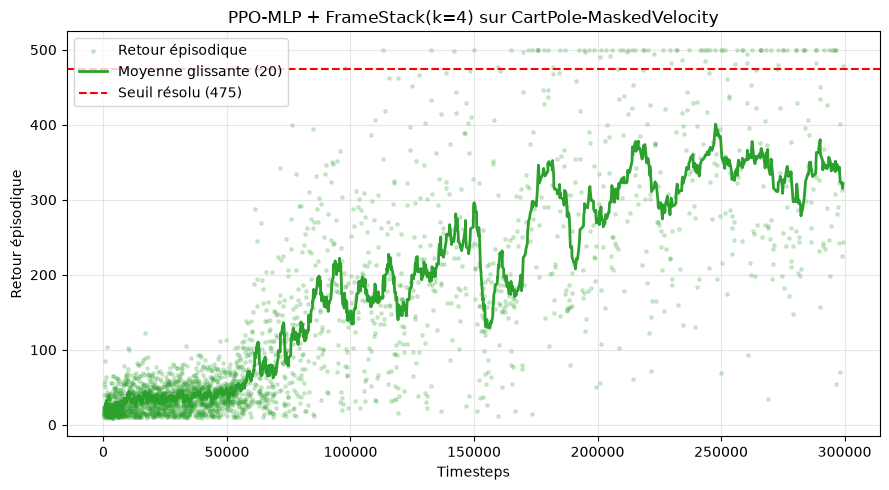

Figure → c:\Users\Pape Malick\works\ppo-recurrent-pomdp\results\csv\ppo_mlp_framestack_masked__seed1.png

Return final (50 derniers ep): 345.90


In [13]:
fig, ax = plt.subplots(1, 1, figsize=(9, 5))
steps = np.array(history["step"])
returns = np.array(history["episodic_return"])
ax.scatter(steps, returns, s=6, alpha=0.2, color="C2", label="Retour épisodique")
if len(returns) >= 20:
    smooth = np.convolve(returns, np.ones(20)/20, mode="valid")
    ax.plot(steps[19:], smooth, color="C2", linewidth=2, label="Moyenne glissante (20)")
ax.axhline(475, color="red", linestyle="--", label="Seuil résolu (475)")
ax.set_xlabel("Timesteps")
ax.set_ylabel("Retour épisodique")
ax.set_title(f"PPO-MLP + FrameStack(k=4) sur CartPole-MaskedVelocity")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
fig_path = ROOT / "results" / "csv" / f"{run_name}.png"
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=120)
plt.show()
print(f"Figure → {fig_path}")
print(f"\nReturn final (50 derniers ep): {np.mean(returns[-50:]):.2f}")

## Sauvegarde

In [14]:
df = pd.DataFrame({"step": history["step"], "return": history["episodic_return"]})
df["config"] = "PPO-MLP+FrameStack / CartPole-Masked (POMDP)"
csv_path = ROOT / "results" / "csv" / f"{run_name}.csv"
df.to_csv(csv_path, index=False)
print(f"CSV → {csv_path}")

model_path = ROOT / "results" / "models" / f"{run_name}.pt"
model_path.parent.mkdir(parents=True, exist_ok=True)
torch.save(agent.state_dict(), model_path)
print(f"Modèle → {model_path}")

CSV → c:\Users\Pape Malick\works\ppo-recurrent-pomdp\results\csv\ppo_mlp_framestack_masked__seed1.csv
Modèle → c:\Users\Pape Malick\works\ppo-recurrent-pomdp\results\models\ppo_mlp_framestack_masked__seed1.pt


## Conclusion intermédiaire

✅ Avec Frame Stacking k=4, PPO-MLP **récupère une grande partie de la performance** perdue à cause de l'observabilité partielle.

**Interprétation :** l'agent apprend implicitement à reconstruire les vitesses depuis l'historique des 4 dernières positions ($\dot{x} \approx x_t - x_{t-1}$, etc.). C'est une stratégie **équivalente en théorie** à ce qu'un LSTM ferait, mais avec un mécanisme beaucoup plus simple.

**Note importante :** un essai de PPO-LSTM est documenté dans NB 03b. Notre implémentation de PPO-LSTM n'a pas convergé dans les conditions testées — un résultat qui rejoint les observations de Ni et al. (2022) sur l'instabilité de PPO-LSTM.